# College Scorecard Provisional Analysis (DOE) 

Hypothesis 1 (College Scorecard): Students who attend more racially and demographically diverse universities will demonstrate higher median earnings after graduation, reflecting the broad economic and social benefits of diverse educational environments.

- Expect that more homogenous universities (excl. HBCU's) will have worse outcomes for students
- Control for: family income distribution, completion rates


In [2]:
#setup chunk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from IPython.display import IFrame

In [3]:
#data cleaning process-- especially making smaller datasets that are more manageable and only include relevant variables

dat = pd.read_csv('../data/Glynn_data/combined_data.csv')
dat.columns

Index(['univ_id', 'univ_name', 'state', 'zip_code', 'hbcu', 'pbi', 'aanapii',
       'hsi', 'tribal', 'percent_pell', 'completion_rate_fry', 'ugds_white',
       'ugds_black', 'ugds_hisp', 'ugds_asian', 'ugds_aian', 'ugds_nhpi',
       'ugds_2mor', 'ugds_nra', 'ugds_unkn', 'ugds_whitenh', 'ugds_blacknh',
       'ugds_api', 'ugds_aianold', 'ugds_hispold', 'ugds_men', 'ugds_women',
       'md_earn_wne_p10', 'md_earn_wne_p6', 'md_earn_wne_p8',
       'md_earn_wne_inc1_p6', 'md_earn_wne_inc2_p6', 'md_earn_wne_inc3_p6',
       'md_earn_wne_indep1_p6', 'md_earn_wne_indep0_p6',
       'md_earn_wne_male0_p6', 'md_earn_wne_male1_p6', 'md_earn_wne_inc1_p8',
       'md_earn_wne_inc2_p8', 'md_earn_wne_inc3_p8', 'md_earn_wne_indep1_p8',
       'md_earn_wne_indep0_p8', 'md_earn_wne_male0_p8', 'md_earn_wne_male1_p8',
       'md_earn_wne_inc1_p10', 'md_earn_wne_inc2_p10', 'md_earn_wne_inc3_p10',
       'md_earn_wne_indep1_p10', 'md_earn_wne_indep0_p10',
       'md_earn_wne_male0_p10', 'md_earn_wne_mal

## variable descriptions: 

- ugds_: different racial/ demographic variables of the student body at a university. Intuitively coded as ugds_suffix, where the suffix is the group (white, black, hispanic, asian, amarican indian and alaska native, native hawaiian and pacific islander, two or more races, norace, unknown, white nonhispanic, blacknonhispanic, asian pacific islander (coded differently for diff years?), )
- MD_earn_: Median earnings are calculated for individuals that were federally aided, were working, and were not enrolled in school as of the measurement point. Earnings were measured based on wages and deferred compensation reported via IRS form W-2 plus positive self-employment earnings reported via Schedule SE. Individuals with $1 or more of earnings were considered to be working and were included in the median earnings calculation.
- 

In [4]:
#other dataset features
dat.info()
dat['univ_id'].nunique()

#despite data cleaning, the actual contents of the dataset that are non zero are pretty slim. I can try to get some of this data back later, 
    #potentially by merging non-missing data from another year for important vars such as hbcu, etc.

<class 'pandas.DataFrame'>
RangeIndex: 13027 entries, 0 to 13026
Data columns (total 85 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   univ_id                 13027 non-null  int64  
 1   univ_name               13027 non-null  str    
 2   state                   13027 non-null  str    
 3   zip_code                13027 non-null  str    
 4   hbcu                    0 non-null      float64
 5   pbi                     0 non-null      float64
 6   aanapii                 0 non-null      float64
 7   hsi                     0 non-null      float64
 8   tribal                  0 non-null      float64
 9   percent_pell            11409 non-null  float64
 10  completion_rate_fry     4544 non-null   float64
 11  ugds_white              11485 non-null  float64
 12  ugds_black              11485 non-null  float64
 13  ugds_hisp               11485 non-null  float64
 14  ugds_asian              11485 non-null  float64
 

6678

In [5]:
#Asked claude for an equivalent to complete.cases() in R to keep only columns with at least some non-null values
dat = dat.dropna(axis=1, how='all')
dat.info()

<class 'pandas.DataFrame'>
RangeIndex: 13027 entries, 0 to 13026
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   univ_id              13027 non-null  int64  
 1   univ_name            13027 non-null  str    
 2   state                13027 non-null  str    
 3   zip_code             13027 non-null  str    
 4   percent_pell         11409 non-null  float64
 5   completion_rate_fry  4544 non-null   float64
 6   ugds_white           11485 non-null  float64
 7   ugds_black           11485 non-null  float64
 8   ugds_hisp            11485 non-null  float64
 9   ugds_asian           11485 non-null  float64
 10  ugds_aian            11485 non-null  float64
 11  ugds_nhpi            11485 non-null  float64
 12  ugds_2mor            11485 non-null  float64
 13  ugds_nra             11485 non-null  float64
 14  ugds_unkn            11485 non-null  float64
 15  ugds_men             11485 non-null  float64
 1

The more simplified data dictionary gives us the university name, its state and zip code, the percent of students who receive pell grants, its completion rate, basic racial and demographic (sex) information about a university's composition, and the median earnings of students four years after graduation. 

In [6]:
#approx equal data for year, but a few universities not captured between year
dat['year'].value_counts()

year
2021    6543
2022    6484
Name: count, dtype: int64

Since I expect that students who attend more racially and demographically diverse universities will demonstrate higher median earnings after graduation, we might expect to see some visual connection between the racial composition of a unviersity and our key outcome variable.


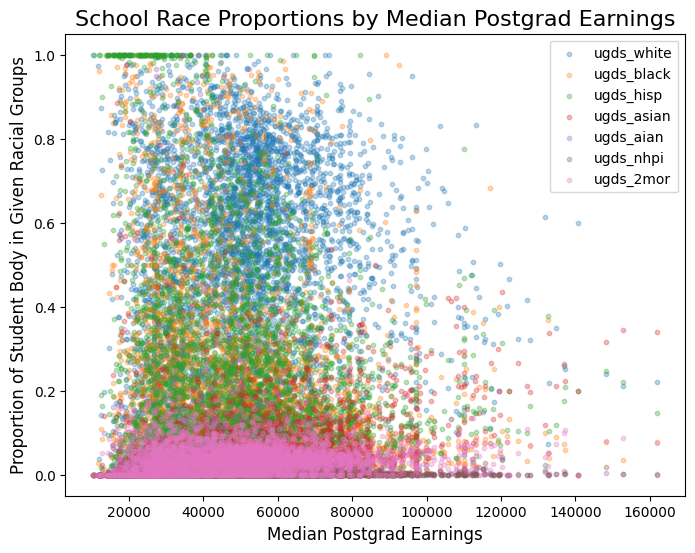

In [7]:
race_cols = ['ugds_white', 'ugds_black', 'ugds_hisp', 'ugds_asian', 'ugds_aian', 
             'ugds_nhpi', 'ugds_2mor']

#convert the IV to numeric: 
dat['md_earn_wne_4yr'] = pd.to_numeric(dat['md_earn_wne_4yr'], errors='coerce')


fig, ax = plt.subplots(figsize = (8,6))

for col in race_cols: 
    ax.scatter(dat['md_earn_wne_4yr'], dat[col], label=col, alpha=0.3, s=10)

ax.set_title("School Race Proportions by Median Postgrad Earnings", fontsize = 16)
ax.set_xlabel('Median Postgrad Earnings', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
plt.legend()

plt.show()

If we did see an effect of *individual* racial groups on postgrad earnings, we would expect a classic linear relationship, where as the proportion of a racial group increases, so do the medeian postgrad earnings. This is somewhat visible at the tail of the Asian American group (pink), where after the earning threshold of 80,000, the earnings seem to increase sas the percent of Asian Americans does at a school. 
There is a similar, albeit less strong relationship at the right end of the right side of White postgrad earnings, but there are also significant outliers skewed toward the bottom of the graph. 

The graph provisionally seems to support our key hypothesis, thatas the proportion of a racial group close to 80% or higher increases, so too does the colleges' expected median earnings. The relative lack of data in the top right corner seems to support this hypothesis, with the highest-earning schools seeming to have a somewhat equally distributed mix of races between 0-0.4% of their student body.  

The first graph demonstrates a few patterns/ outliers to explore and correct here: 
1. There are quite a few hispanic dots clustered at the top of the distribution at exactly 1, indicating completely hispanic universities, perhaps? This seems reasonable, except that there aren't equivalent clustering patterns for other racial groups. for the most part.
2. The outliers at the right end of the earnings axis seem to resemble one another. Check what universities these are, and what their racial composition is. My guess is that highly selective universities can tailor their student body to be some combination of representative and diverse in a way that less seelctive universities (who probably have worse earning outcomes) cannot.  


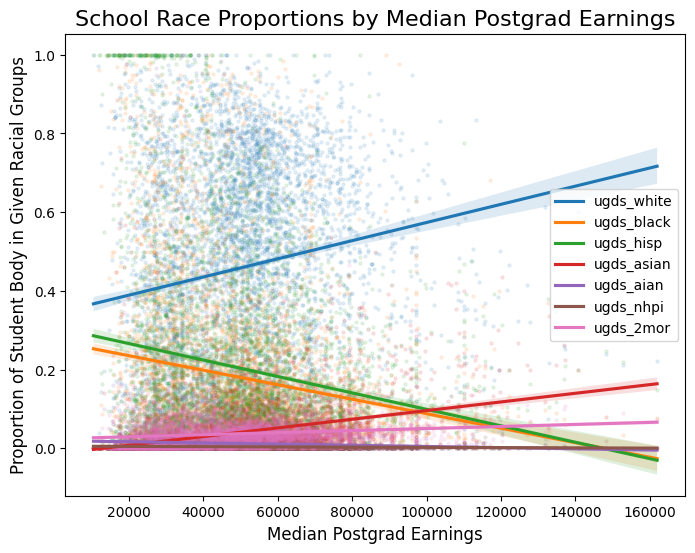

In [8]:
#changing to a regression plot to see clearer trends between racial groups

fig, ax = plt.subplots(figsize = (8,6))

for col in race_cols: 
    sns.regplot(data = dat, x = 'md_earn_wne_4yr', y = col,  
                scatter_kws = {'alpha': 0.1, 's':5}, 
                line_kws = {'label': col}, 
                ax = ax)

ax.set_title("School Race Proportions by Median Postgrad Earnings", fontsize = 16)
ax.set_xlabel('Median Postgrad Earnings', fontsize=12)
ax.set_ylabel('Proportion of Student Body in Given Racial Groups', fontsize=12)
plt.legend()

plt.show()

When we plot this as regression lines, however, we see something different. Generally, as the proportion of a student body who is white increases, so too does the median earnigns of a school. However, this seems to stop being a positive trend after white people befome over 70% of a student body (that is, as the school becomes disproportionately white, the earnings are less consistently high). The same general pattern is true for Asian students, where schools that have higher percentages of these students also tend to report better median earnings for their students later on. We might explain this through racial biases in the labor market, and the socioeconomically advantaged position of White and Asian Americans for the most part, who are overrepresetned in the [middle and upper classes](https://www.pewresearch.org/race-and-ethnicity/2024/05/31/the-state-of-the-asian-american-middle-class/), with respect to their proportions in the populaition 


Conversely, among schools who increase their shares of Black and Latino students, median earnings tend to go down. We can explain these results in the same way; they are a reflection of Black and Hispanic Americans' experiences of racism and structural inequality.


### Next steps: 
- Go back and exclude non undergraduate program universities (e.g. medical schools)
- See if you can get university tuition
- Merge with HBCU/ other specifically designated university types
- Investigate the outliers at the upper end of the earnings
- Investigate universities who are outliers in percent of student body == 1
- Create diversity index
- Create representativeness index
- Regression (incl. controls for pell grants and completion rates)

In [24]:
#Expect that more homogenous universities (excl. HBCU’s) will have worse outcomes for students
dat[dat['md_earn_wne_4yr']>=140000]

,univ_id,univ_name,state,zip_code,percent_pell,completion_rate_fry,ugds_white,ugds_black,ugds_hisp,ugds_asian,ugds_aian,ugds_nhpi,ugds_2mor,ugds_nra,ugds_unkn,ugds_men,ugds_women,md_earn_wne_4yr,year
6733,110404,California Institute of Technology,CA,91125,0.1398,0.9404,0.2118,0.0346,0.2200,0.3442,0.0010,0.0010,0.0886,0.0937,0.0051,0.5468,0.4532,152843.0,2022
6756,110699,University of California-San Francisco,CA,94143-0244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,151742.0,2022
6796,112525,Western University of Health Sciences,CA,91766-1854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,142369.0,2022
6951,122296,Samuel Merritt University,CA,94609,0.1827,NaN,0.2389,0.0786,0.2478,0.3160,0.0030,0.0178,0.0801,0.0000,0.0178,0.2062,0.7938,148182.0,2022
7451,146490,Lake Forest Graduate School of Management,IL,60045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,171206.0,2022
7979,166683,Massachusetts Institute of Technology,MA,02139-4301,0.1843,0.9494,0.2208,0.0781,0.1481,0.3409,0.0017,0.0004,0.0744,0.1102,0.0254,0.5177,0.4823,161961.0,2022
7981,166708,University of Massachusetts Chan Medical School,MA,01655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140623.0,2022
9595,220996,Middle Tennessee School of Anesthesia Inc,TN,37115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203018.0,2022
10468,385415,Albert Einstein College of Medicine,NY,10461-1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178564.0,2022
10536,407629,Lake Erie College of Osteopathic Medicine,PA,16509-1025,0.0000,NaN,0.6000,0.0000,0.2000,0.2000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1000,0.9000,140695.0,2022


In [ ]:
#Control for: family income distribution, completion rates